In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [2]:
def luu_file(filename, u, err, L_x, L_y, k):
    n_x = u.shape[0]  # kich thuoc luoi nx
    n_y = u.shape[1]  # kich thuoc luoi ny

    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tai vong lap {k}\n")
        file.write(f"### Max error = {np.max(err):.6e}\n")
        file.write("#" * 80 + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'T':>15s} {'Error':>15s}\n")

        for i in range(n_x):
            for j in range(n_y):
                x = i * L_x / (n_x - 1)
                y = j * L_y / (n_y - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i,j]:15.6f} {err[i,j]:15.6e}\n")
            file.write("\n")

In [3]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L_x, L_y        : chieu dai mien tinh toan, vi du mien [0, L_x] x [0, L_y]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so

def hamtinh_laplace_gauss_seidel(u, L_x, L_y, N_max=100000, err_max=1e-6, filename="bai1"):
    #global h, rho, x, y
    n_x = u.shape[0]  # kich thuoc luoi nx
    n_y = u.shape[1]  # kich thuoc luoi ny

    h_x = L_x / (n_x - 1)
    h_y = L_y / (n_y - 1)

    hx2 = h_x**2
    hy2 = h_y**2

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n_x - 1):
            for j in range(1, n_y - 1):
                u[i, j] = (
                    hy2 * (u[i + 1, j] + u[i - 1, j])
                    + hx2 * (u[i, j + 1] + u[i, j - 1])
                ) / (2 * (hx2 + hy2))

        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L_x, L_y, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L_x, L_y, N_max)

    return u

In [4]:
# u        : mang nghiem kich thuoc n x n, da gan san dieu kien bien
# L        : chieu dai mien tinh toan, vi du mien [0, L] x [0, L]
# N_max    : so lan lap toi da neu chua hoi tu
# err_max  : nguong sai so hoi tu, dung khi max|u_moi - u_cu| < err_max
# filename : ten file output dung de luu nghiem va sai so

def hamtinh_laplace_jacobi(u, L_x, L_y, N_max=100000, err_max=1e-6, filename="bai1"):
    n_x = u.shape[0]  # kich thuoc luoi nx
    n_y = u.shape[1]  # kich thuoc luoi ny

    # global h, rho, x, y # dung khi can su dung dang co dien tich

    h_x = L_x / (n_x - 1)
    h_y = L_y / (n_y - 1)

    hx2 = h_x**2
    hy2 = h_y**2

    # lap toi da N_max lan
    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        u_new = u.copy()  # tao mang nghiem moi

        # cap nhat cac diem ben trong mien bang phuong phap Jacobi
        # tat ca gia tri moi deu duoc tinh tu u_old
        u_new[1:-1, 1:-1] = (
            hy2 * (
                u_old[2:, 1:-1]     # diem ben phai
                + u_old[:-2, 1:-1]  # diem ben trai
            )
            + hx2 * (
                u_old[1:-1, 2:]     # diem ben tren
                + u_old[1:-1, :-2]  # diem ben duoi
            )
        ) / (2 * (hx2 + hy2))

        # QUANTRONG:
        # DUNG KHI LA PHUONG TRINH POISSON dang:
        #
        # d2u/dx2 + d2u/dy2 = - pi*rho(x,y)
        #
        # u_new[i, j] = (
        #     hy2 * (u_old[i + 1, j] + u_old[i - 1, j])
        #     + hx2 * (u_old[i, j + 1] + u_old[i, j - 1])
        #     + hx2 * hy2 * np.pi * rho(x[i], y[j])           # neu de cho = -pi rho thi dau la +, neu +pi rho thi la -
        # ) / (2 * (hx2 + hy2))

        u = u_new  # cap nhat nghiem moi

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Jacobi hoi tu sau {k} vong lap, max_err = {max_err:.3e}")
            luu_file(filename + "_jacobi_result.txt", u, err, L_x, L_y, k)
            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Jacobi khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")

    
    luu_file(filename + "_jacobi_result_khonghoitu.txt", u, err, L_x, L_y, N_max)
    return u

In [5]:
#u[i, 0]     = bottom
#u[i, n-1]   = top
#u[0, j]     = left
#u[n-1, j]   = right

# n_x la so diem luoi, n_x -1 so doan chia

#T(x, L_y) = 100 *np.sin(np.pi* x/L_x)
# x_i = i * L/(n_x-1)
# x_i/L_x = i / (n_x-1)

def tao_bien_hinhchunhat(n_x, n_y, u_bottom, u_left, u_right, u_top):
    u = np.zeros((n_x, n_y), dtype=float)

    u[:, 0] = u_bottom
    u[0, :] = u_left
    u[-1, :] = u_right

    for i in range(n_x):
        u[i, -1] = u_top * np.sin(np.pi * i / (n_x-1)) 
    return u

In [17]:
L_x = 200 # Chieu dai hop x
L_y = 100 # Chieu dai hop y

n_x = 126 # so diem chia truc x
n_y = 76 # so diem chia truc y


N_max = 100000 # So vong lap toi da
err_max = 1e-6 # Sai so

T_xungquanh = 0 

T_trencung_heso = 100 

T_nhietdo_bankimloai = tao_bien_hinhchunhat(n_x, n_y, T_xungquanh, T_xungquanh, T_xungquanh, T_trencung_heso)

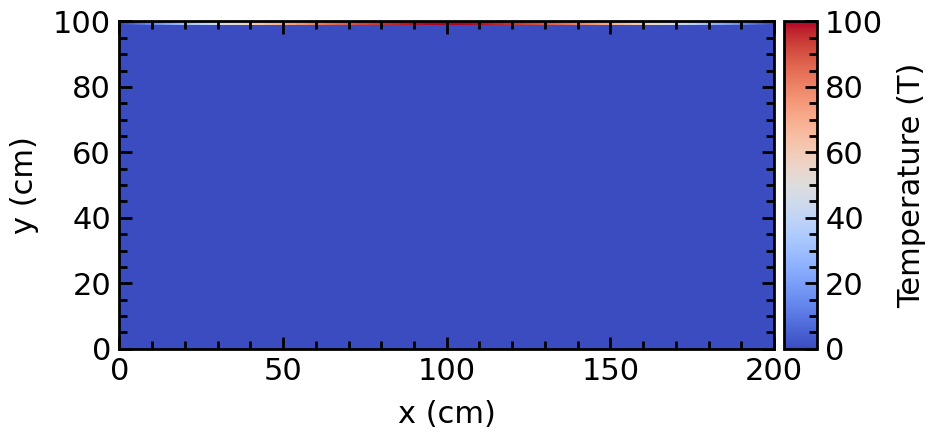

In [18]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    T_nhietdo_bankimloai.T,
    origin='lower',
    cmap='coolwarm',
    extent=[0, 200, 0, 100], 
    # extent nói cho imshow biết ảnh của mình tương ứng trực tiếp với miền vật lý thay vi dung plt.xlim(0, 200) plt.ylim(0, 100)
    aspect='equal',
    vmin=0,
    vmax=100
)

ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')

# Tao colorbar co chieu cao bang truc ax
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Temperature (T)')

plt.show()

In [19]:
T_nhietdo_bankimloai_gs = hamtinh_laplace_gauss_seidel(T_nhietdo_bankimloai, L_x, L_y, N_max=100000, err_max=1e-6, filename="bai1_gpt")

Gauss-Seidel hoi tu sau 8590 vong lap, max_err = 9.992e-07


In [ ]:
T_nhietdo_bankimloai = tao_bien_hinhchunhat(n_x, n_y, T_xungquanh, T_xungquanh, T_xungquanh, T_trencung_heso)

In [21]:
T_nhietdo_bankimloai_gs = hamtinh_laplace_jacobi(T_nhietdo_bankimloai, L_x, L_y, N_max=100000, err_max=1e-6, filename="bai1_gpt")

Jacobi hoi tu sau 16071 vong lap, max_err = 9.995e-07


## Doc file va ve hinh

In [7]:
def doc_file_ketqua(filename):
    x, y, V, err = np.loadtxt(filename, unpack=True, comments="#")

    # Lay so diem luoi that su tu file
    x_unique = np.unique(x)
    y_unique = np.unique(y)

    nx = len(x_unique)
    ny = len(y_unique)

    print("File:", filename)
    print("nx =", nx)
    print("ny =", ny)
    print("So diem trong file =", len(x))
    print("nx * ny =", nx * ny)

    if nx * ny != len(x):
        raise ValueError("File khong phai luoi chu nhat day du")

    # Neu file luu theo for i rồi for j
    X = x.reshape(nx, ny)
    Y = y.reshape(nx, ny)
    V2D = V.reshape(nx, ny)
    err2D = err.reshape(nx, ny)

    return x_unique, y_unique, X, Y, V2D, err2D

In [8]:
x_jacobi_unique, y_jacobi_unique, X_jacobi_bai1, Y_jacobi_bai1, V2D_jacobi_bai1, err2D_jacobi_bai1 = doc_file_ketqua(
    "bai1_gpt_jacobi_result.txt"
)

File: bai1_gpt_jacobi_result.txt
nx = 126
ny = 76
So diem trong file = 9576
nx * ny = 9576


In [13]:
x_gs_unique, y_gs_unique, X_gs_bai1, Y_gs_bai1, V2D_gs_bai1, err2D_gs_bai1 = doc_file_ketqua(
    "bai1_gpt_gs_result.txt"
)

File: bai1_gpt_gs_result.txt
nx = 126
ny = 76
So diem trong file = 9576
nx * ny = 9576


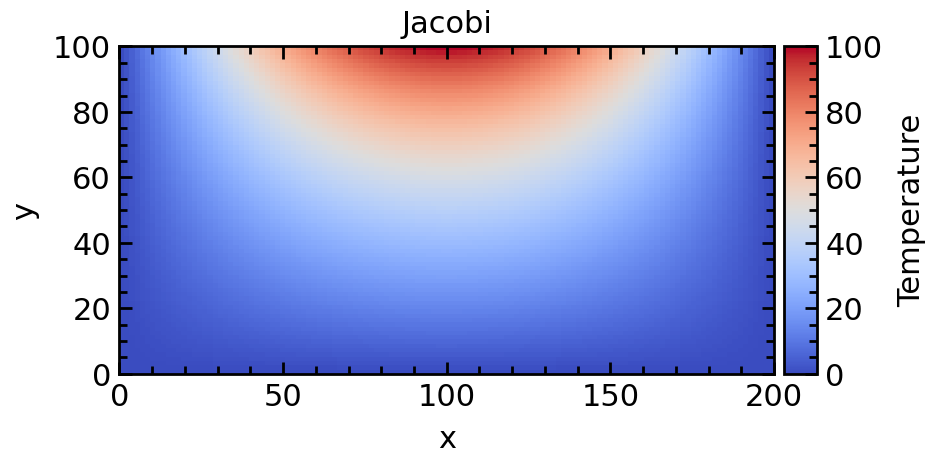

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    V2D_jacobi_bai1.T,
    origin="lower",
    extent=[
        x_jacobi_unique.min(), x_jacobi_unique.max(),
        y_jacobi_unique.min(), y_jacobi_unique.max()
    ],
    cmap="coolwarm",
    aspect="equal",
    vmin=0,
    vmax=100
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Jacobi")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Temperature")
cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.savefig("bai1_gpt_jacobi.png", dpi = 300)

plt.show()

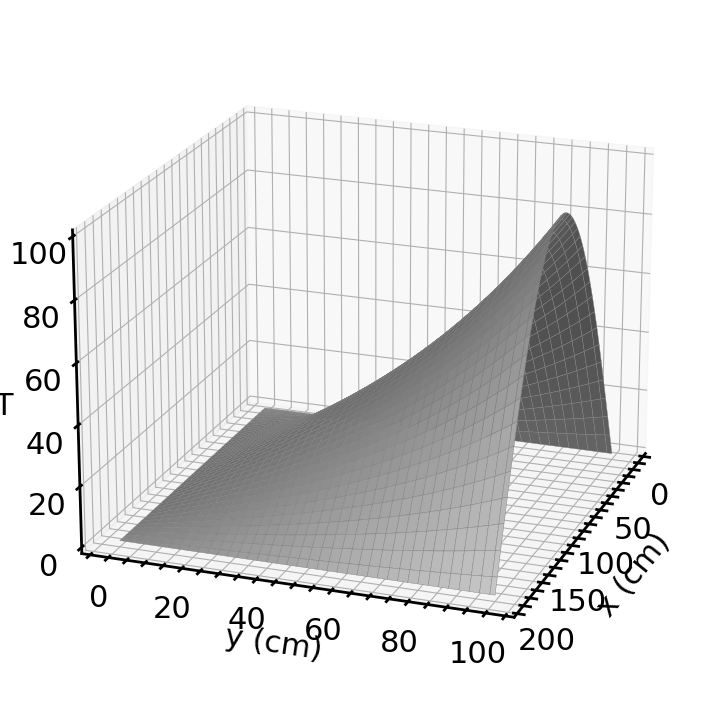

In [15]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

X_jacobi_bai1_ve3d, Y_jacobi_bai1_ve3D = np.meshgrid(X_jacobi_bai1, Y_jacobi_bai1) # Gia su neu nhu khong chung shape la khong ve duoc

ax.plot_surface(X_jacobi_bai1, Y_jacobi_bai1, V2D_jacobi_bai1, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('T')
ax.view_init(elev=20, azim=20)
plt.savefig("bai1_gpt_jacobi_3D.png", dpi=300)
plt.show()

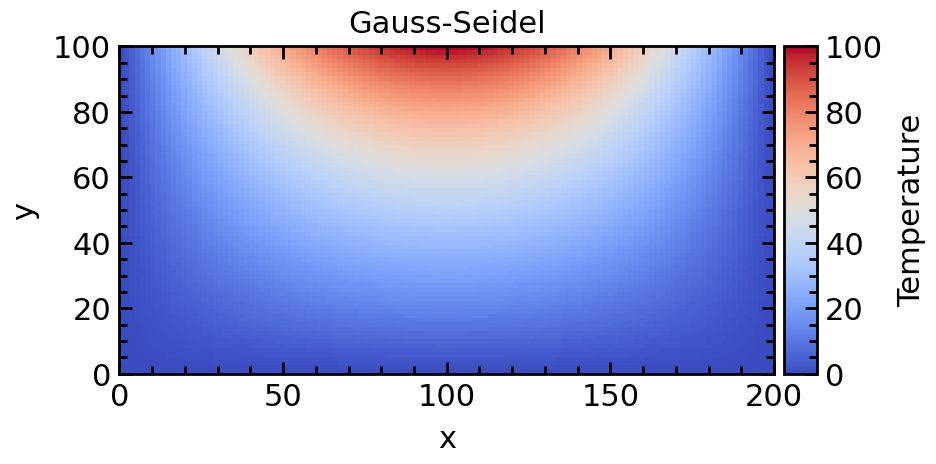

: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    V2D_gs_bai1.T,
    origin="lower",
    extent=[
        x_gs_unique.min(), x_gs_unique.max(),
        y_gs_unique.min(), y_gs_unique.max()
    ],
    cmap="coolwarm",
    aspect="equal",
    vmin=0,
    vmax=100
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Gauss-Seidel")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Temperature")
cbar.set_ticks([0, 20, 40, 60, 80, 100])

plt.savefig("bai1_gpt_gauss.png", dpi = 300)

plt.show()